Suabizado / desenfoque  de punto de interes

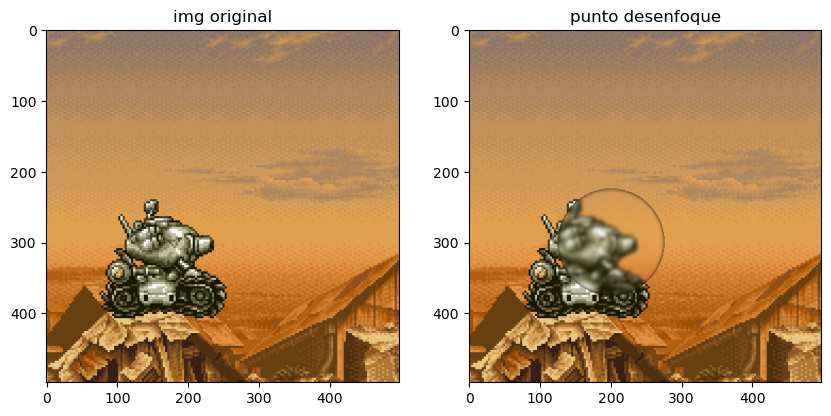

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoquePDT(img, centro, x, y):
    img1 = np.copy(img)
    valx,valy = centro
    mediax = x//2
    mediaY = y//2
    mascara = np.zeros_like(img, dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediax,mediaY),0,0,360,(255,255,255),-1)
    img_mask = cv2.bitwise_and(img,mascara)
    desenmfoque = cv2.GaussianBlur(img_mask,(15,15),0)
    img1[mascara!=0] = desenmfoque[mascara!=0]
    return img1

img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_desenfoque = desenfoquePDT(imgRGB,(200,300),150,150)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')

plt.subplot(1,2,2)
plt.title('punto desenfoque')
plt.imshow(img_desenfoque, cmap='gray')

plt.show()

Bordes y mascaras

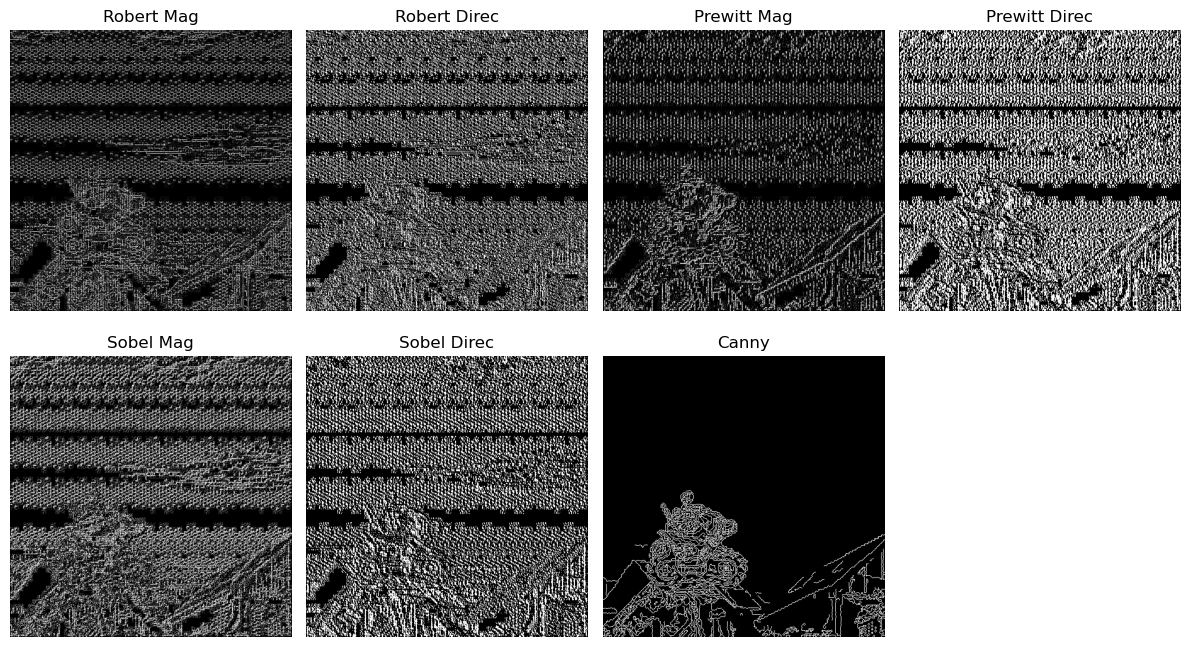

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imgGIF3.jpg')
imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#KERNEL ROBERTS
robertsx = np.array([[-1,0],[0,1]])
robertsy = np.array([[0,-1],[1,0]])

#motrar x y y
img_robx = cv2.filter2D(imgGray,-1,robertsx)
img_roby = cv2.filter2D(imgGray,-1,robertsy)

#magnitud en roberts
rob_gMagnitud = np.sqrt(img_robx**2+img_roby**2)
rob_gDireccion = np.arctan2(img_roby,img_robx) #simular un filtro prewitt

#filtro prewitt
#kernels
prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitty = np.array([[1,1,0],[0,0,0],[-1,-1,-1]])

img_prewx = cv2.filter2D(imgGray,-1,prewittx)
img_prewy = cv2.filter2D(imgGray,-1,prewitty)

prew_mag = np.sqrt(img_prewx**2+img_prewy**2)
prew_direc = np.arctan2(img_prewx,img_prewy)

#filtro sobel
#kernel
sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

img_sobx = cv2.filter2D(imgGray,-1,sobelx)
img_soby = cv2.filter2D(imgGray,-1,sobely)

sob_mag = np.sqrt(img_sobx**2+img_soby**2)
sob_direc = np.arctan2(img_sobx,img_soby)

canny = cv2.Canny(imgGray,100,200)

plt.figure(figsize=(12, 10))

plt.subplot(3, 4, 1)
plt.imshow(rob_gMagnitud, cmap='gray')
plt.title('Robert Mag')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(rob_gDireccion, cmap='gray')
plt.title('Robert Direc')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.imshow(prew_mag, cmap='gray')
plt.title('Prewitt Mag')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.imshow(prew_direc, cmap='gray')
plt.title('Prewitt Direc')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(sob_mag, cmap='gray')
plt.title('Sobel Mag')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.imshow(sob_direc, cmap='gray')
plt.title('Sobel Direc')
plt.axis('off')

plt.subplot(3, 4, 7)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

Roberts

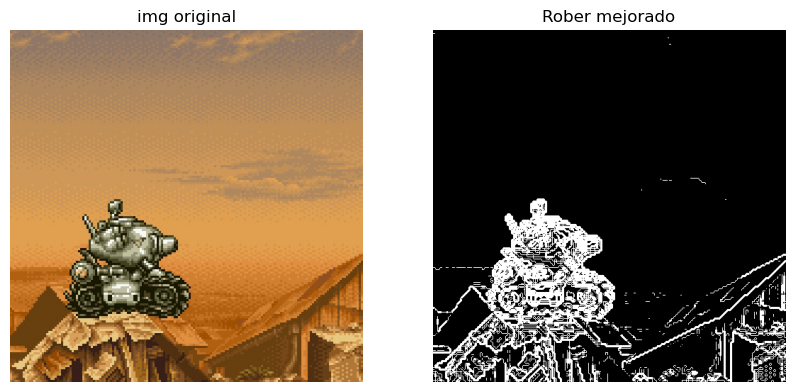

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def roberts_mejorado(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    kernelx = np.array([[-2,0],[0,2]],dtype=np.float32)
    kernely = np.array([[0,-2],[2,0]],dtype=np.float32)

    robx = cv2.filter2D(suabizado,cv2.CV_16S,kernelx)
    roby = cv2.filter2D(suabizado,cv2.CV_16S,kernely)

    roberts = cv2.addWeighted(np.abs(robx),0.7,np.abs(roby),0.7,0)
    #resaltar mas los bordes
    _,bordes = cv2.threshold(roberts,30,255,cv2.THRESH_BINARY)
    return bordes

img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgRob = roberts_mejorado(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Rober mejorado')
plt.imshow(imgRob, cmap='gray')
plt.axis('off')

plt.show()

Sobel Mejorado

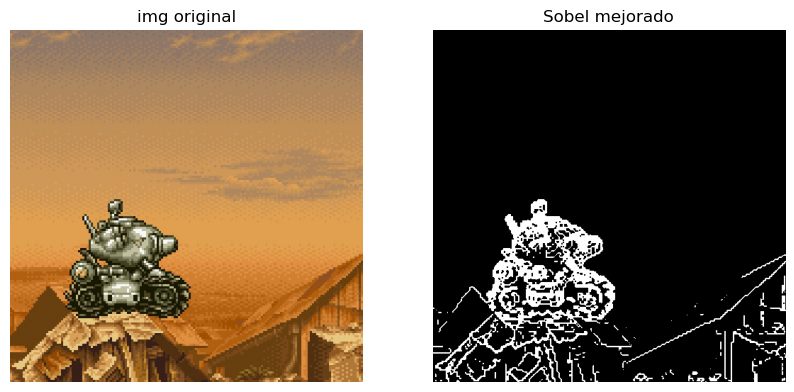

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobel_mejorado(img,tam_kernel=3,umbral=30):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    sobelx = cv2.Sobel(suabizado, cv2.CV_64F,1,0,ksize=tam_kernel)
    sobely = cv2.Sobel(suabizado, cv2.CV_64F,0,1,ksize=tam_kernel)

    magnitud = np.sqrt(sobelx**2+sobely**2)

    magnitud = cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)

    _,bordes = cv2.threshold(magnitud,umbral,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU) #agregar o quitar otsu
    #unir bordes rotos
    kerner_morfologico = np.ones((2,2),np.uint8)
    bordes = cv2.morphologyEx(bordes,cv2.MORPH_CLOSE, kerner_morfologico)

    return bordes


img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgSob = sobel_mejorado(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Sobel mejorado')
plt.imshow(imgSob, cmap='gray')
plt.axis('off')

plt.show()

Prewitt Mejorado

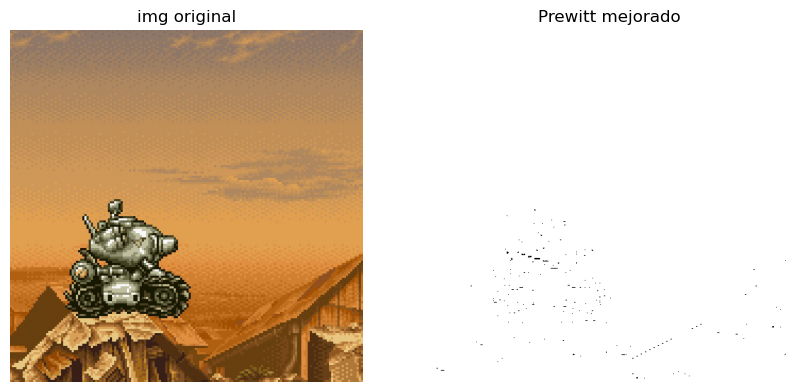

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def prewitt_mejorado(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    prewittx = np.array([[3,0,-3],[3,0,-3],[3,0,-3]],dtype=np.float32)
    prewitty = np.array([[3,3,0],[0,0,0],[-3,-3,-3]],dtype=np.float32)

    prewx = cv2.filter2D(suabizado,cv2.CV_64F,prewittx)
    prewy = cv2.filter2D(suabizado,cv2.CV_64F,prewitty)

    magnitud = np.sqrt(prewx**2+prewy**2)
    _,bordes = cv2.threshold(magnitud,30,255,cv2.THRESH_BINARY)
    return bordes

img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgPrew = prewitt_mejorado(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Prewitt mejorado')
plt.imshow(imgPrew, cmap='gray')
plt.axis('off')

plt.show()

Funciones

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def roberts_mejorado(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    kernelx = np.array([[-2,0],[0,2]],dtype=np.float32)
    kernely = np.array([[0,-2],[2,0]],dtype=np.float32)

    robx = cv2.filter2D(suabizado,cv2.CV_16S,kernelx)
    roby = cv2.filter2D(suabizado,cv2.CV_16S,kernely)

    roberts = cv2.addWeighted(np.abs(robx),0.7,np.abs(roby),0.7,0)
    #resaltar mas los bordes
    _,bordes = cv2.threshold(roberts,30,255,cv2.THRESH_BINARY)
    return bordes

def roberts_norm(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    robertsx = np.array([[-1,0],[0,1]])
    robertsy = np.array([[0,-1],[1,0]])

    img_robx = cv2.filter2D(img_gray,-1,robertsx)
    img_roby = cv2.filter2D(img_gray,-1,robertsy)

    rob_gMagnitud = np.sqrt(img_robx**2+img_roby**2)
    rob_gDireccion = np.arctan2(img_roby,img_robx) 

    return rob_gMagnitud,rob_gDireccion

def prewitt_mejorado(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    prewittx = np.array([[3,0,-3],[3,0,-3],[3,0,-3]],dtype=np.float32)
    prewitty = np.array([[3,3,0],[0,0,0],[-3,-3,-3]],dtype=np.float32)

    prewx = cv2.filter2D(suabizado,cv2.CV_64F,prewittx)
    prewy = cv2.filter2D(suabizado,cv2.CV_64F,prewitty)

    magnitud = np.sqrt(prewx**2+prewy**2)
    _,bordes = cv2.threshold(magnitud,30,255,cv2.THRESH_BINARY)
    return bordes

def prewitt_norm(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
    prewitty = np.array([[1,1,0],[0,0,0],[-1,-1,-1]])

    img_prewx = cv2.filter2D(img_gray,-1,prewittx)
    img_prewy = cv2.filter2D(img_gray,-1,prewitty)

    prew_mag = np.sqrt(img_prewx**2+img_prewy**2)
    prew_direc = np.arctan2(img_prewx,img_prewy)

    return prew_mag,prew_direc

def sobel_mejorado(img,tam_kernel=3,umbral=30):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    sobelx = cv2.Sobel(suabizado, cv2.CV_64F,1,0,ksize=tam_kernel)
    sobely = cv2.Sobel(suabizado, cv2.CV_64F,0,1,ksize=tam_kernel)

    magnitud = np.sqrt(sobelx**2+sobely**2)

    magnitud = cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)

    _,bordes = cv2.threshold(magnitud,umbral,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU) #agregar o quitar otsu
    #unir bordes rotos
    kerner_morfologico = np.ones((2,2),np.uint8)
    bordes = cv2.morphologyEx(bordes,cv2.MORPH_CLOSE, kerner_morfologico)

    return bordes

def sobel_norm(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
    sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

    img_sobx = cv2.filter2D(img_gray,-1,sobelx)
    img_soby = cv2.filter2D(img_gray,-1,sobely)

    sob_mag = np.sqrt(img_sobx**2+img_soby**2)
    sob_direc = np.arctan2(img_sobx,img_soby)

    return sob_mag, sob_direc


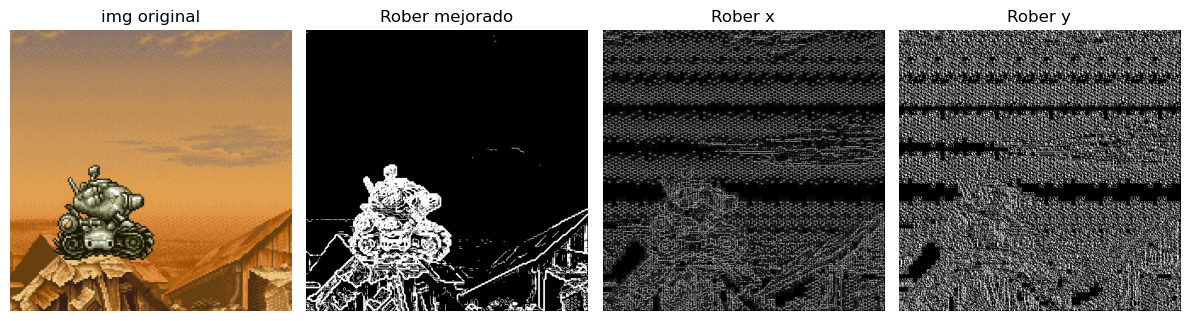

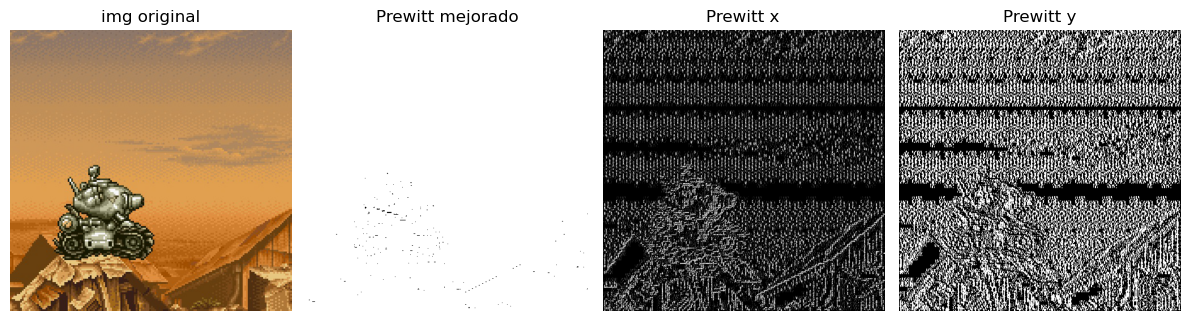

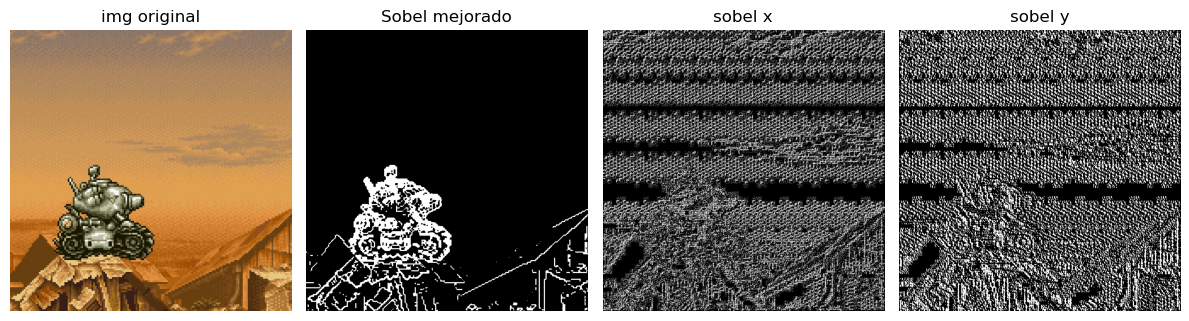

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Roberts
imgRob = roberts_mejorado(img)
imgR1,imgR2=roberts_norm(img)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title('Rober mejorado')
plt.imshow(imgRob, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title('Rober x')
plt.imshow(imgR1, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title('Rober y')
plt.imshow(imgR2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

#prewitts
imgPrew = prewitt_mejorado(img)
imgP1,imgP2=prewitt_norm(img)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title('Prewitt mejorado')
plt.imshow(imgPrew, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title('Prewitt x')
plt.imshow(imgP1, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title('Prewitt y')
plt.imshow(imgP2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

#Sobel
imgSob = sobel_mejorado(img)
imgS1,imgS2 = sobel_norm(img)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title('Sobel mejorado')
plt.imshow(imgSob, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title('sobel x')
plt.imshow(imgS1, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title('sobel y')
plt.imshow(imgS2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()